In [1]:
def getDist(cord1,cord2):
    return (
        (float(cord1[0])-float(cord2[0]))**2+
        (float(cord1[1])-float(cord2[1]))**2+
        (float(cord1[2])-float(cord2[2]))**2)**0.5 * 10

class gro:    # ndx = {chineID : (start atomNdx, end atomNdx)}
    def __init__(self, groFile, proAtomNdx, ligAtomNdx):
        from tqdm import tqdm
        self.version = "groObj V.2"
        self.type = "Multi Chains"
        with open(groFile, "r") as gro:
            groLines = gro.readlines()
            self.atomNum = groLines[1]
        self.frames = {} # { frameNdx : { atomNdx : { resNdx : x, coord : (x, y, x) } } }
        frameNdx = 0
        atomDic = {}
        resNdx = groLines[2].split()[:-3]
        for line in tqdm(groLines[2:]):
            line_list = line.split()
            if len(line_list) == 3:
                self.frames[frameNdx] = atomDic
                # self.getResData(frameNdx)
                frameNdx = frameNdx + 1
                atomDic = {}
            elif "Title" not in line and len(line.split()) > 3:
                #print(line)
                atomNdx = int(line.split()[2])
                atomDic[atomNdx] = {
                    "resNdx" : int(line.split()[0][:-3]),
                    "coord" : (
                        float(line.split()[3]),
                        float(line.split()[4]),
                        float(line.split()[5])
                    )
                }
        print("> getting resData")
        resData = {
            "proRes": self.getRes(ndx=proAtomNdx),
            "ligRes": self.getRes(ndx=ligAtomNdx)
            }
        import pickle
        print("> saving resData")
        with open("resData.pkl", "wb") as resDataF:
            pickle.dump(resData, resDataF)
    def getRes(self, ndx):
        frameDic = {} # { frameNdx : { resNdx : { atomNdx : (coord) } } }
        for frame in self.frames.items():# { frameNdx : { atomNdx : { resNdx : x, coord : (x, y, x) } } }
            frameNdx = frame[0]
            atomDic = frame[1]
            resDic = {}
            for atomNdx in range(ndx[0], ndx[1]+1):
                resNdx = atomDic[atomNdx]["resNdx"]
                coord = atomDic[atomNdx]["coord"]
                if resNdx not in list(resDic.keys()):
                    resDic[resNdx] = [coord]
                else:
                    resDic[resNdx].append(coord)
            frameDic[frameNdx] = resDic
        return frameDic
    # def getResData(self, frameNdx):
    #     import pickle as pkl
    #     proAtomNdx = (1, 1603)
    #     ligAtomNdx = (2864, 2936)
    #     proRes = self.getRes(proAtomNdx)[frameNdx]
    #     ligRes = self.getRes(ligAtomNdx)[frameNdx]
    #     data = {
    #         "frameNdx": frameNdx,
    #         "proRes": proRes,
    #         "ligRes": ligRes
    #         }
    #     with open(f"./framesPkls/{frameNdx}.pkl", "wb") as dataFile:
    #         pkl.dump(data, dataFile)
    #     return 1

def contactPerFrame(frameNdx, proAtomNdx, ligAtomNdx, groObj):
    import pandas as pd
    import pickle
    print("> start")
    with open(groObj, "rb") as groDataFile:
        groData = pickle.load(groDataFile)
    print("> read done")
    ligRes = groData.getRes(ligAtomNdx)[frameNdx]
    proRes = groData.getRes(proAtomNdx)[frameNdx]
    #print(proRes[15])
    print("> getRes done")
    distDic = {}
    ligCoords = []
    for coord in ligRes.items():
        ligCoords = ligCoords + coord[1]
    print("> ligCoords get done")
    for resID in proRes.keys():
        tmpDislist = []
        for resCoords in proRes[resID]:
            for ligCoord in ligCoords:
                #print(resAtom)
                tmpDislist.append(
                    getDist(resCoords, ligCoord)
                )
        distDic[resID] = round(min(tmpDislist), 3)
    print("clt done")
    #print(distDic)
    distDic["frameNdx"] = frameNdx
    dataFrame = pd.DataFrame([distDic])
    return dataFrame

def contactPerFrame_v2(frameNdx, alert = 0):
    import pandas as pd
    import pickle
    if alert: print("> start")
    with open(f"./resData.pkl", "rb") as resDataF:
        resData = pickle.load(resDataF)
    if alert: print("> read done")
    ligRes = resData["ligRes"][frameNdx]
    proRes = resData["proRes"][frameNdx]
    # print("> getRes done")
    distDic = {}
    ligCoords = []
    for coord in ligRes.items():
        ligCoords = ligCoords + coord[1]
    if alert: print("> ligCoords get done")
    for resID in proRes.keys():
        tmpDislist = []
        for resCoords in proRes[resID]:
            for ligCoord in ligCoords:
                #print(resAtom)
                tmpDislist.append(
                    getDist(resCoords, ligCoord)
                )
        distDic[resID] = round(min(tmpDislist), 3)
    if alert: print("> clt done")
    distDic["frameNdx"] = frameNdx
    dataFrame = pd.DataFrame([distDic])
    return dataFrame

In [3]:
groData = gro("../3_md/trjconv/fit.gro", (1, 1603), (2864, 3188))
import pickle
with open("groData.pkl", "wb") as groDataFile:
    pickle.dump(groData, groDataFile)

100%|██████████| 15958189/15958189 [08:36<00:00, 30923.94it/s]


> getting resData
> saving resData


In [4]:
import pickle as pkl
with open("./resData.pkl", "rb") as resDataF:
    resData = pkl.load(resDataF)

In [5]:
resData["proRes"][0]

{15: [(5.01, 5.28, 2.743),
  (5.092, 5.275, 2.679),
  (5.027, 5.369, 2.794),
  (4.92, 5.291, 2.691),
  (5.02, 5.172, 2.845),
  (4.998, 5.072, 2.81),
  (5.167, 5.189, 2.901),
  (5.169, 5.245, 2.998),
  (5.248, 5.236, 2.842),
  (5.239, 5.057, 2.942),
  (5.243, 4.992, 2.852),
  (5.191, 5.0, 3.024),
  (5.39, 5.067, 2.978),
  (5.396, 5.116, 3.077),
  (5.438, 5.135, 2.904),
  (5.45, 4.935, 2.978),
  (5.388, 4.862, 2.948),
  (5.578, 4.909, 2.955),
  (5.671, 5.0, 2.991),
  (5.646, 5.084, 3.039),
  (5.766, 4.972, 2.976),
  (5.617, 4.791, 2.909),
  (5.55, 4.723, 2.883),
  (5.715, 4.787, 2.886),
  (4.925, 5.202, 2.97),
  (4.883, 5.317, 2.991)],
 16: [(4.899, 5.098, 3.057),
  (4.936, 5.006, 3.042),
  (4.809, 5.097, 3.174),
  (4.717, 5.149, 3.151),
  (4.771, 4.949, 3.201),
  (4.725, 4.942, 3.303),
  (4.862, 4.885, 3.201),
  (4.662, 4.898, 3.098),
  (4.593, 4.981, 3.07),
  (4.583, 4.842, 3.153),
  (4.714, 4.809, 2.983),
  (4.677, 4.849, 2.87),
  (4.79, 4.713, 3.003),
  (4.881, 5.165, 3.291),
  (5.00

In [2]:
contactPerFrame_v2(0, 1)

> start
> read done
> ligCoords get done
> clt done


,15,16,17,18,19,20,21,22,23,24,...,107,108,109,110,111,112,113,114,115,frameNdx
0,11.877,12.262,10.095,3.724,1.968,8.524,8.63,1.62,6.301,2.035,...,5.074,2.364,5.896,6.305,8.616,12.318,13.195,13.572,15.611,0


In [2]:
from joblib import Parallel, delayed
from tqdm import tqdm
import pickle
import pandas as pd
results = Parallel(
    n_jobs=10, backend='multiprocessing'
    )(delayed(contactPerFrame_v2)(frameNdx, 0) for frameNdx in tqdm(range(0,5001)))
results = pd.concat(results, axis=0, ignore_index=True)
results = results.sort_values(by=results.columns[-1], ascending=True)
with open("con_results.pkl", "wb") as con_results:
    pickle.dump(results, con_results)


100%|██████████| 5001/5001 [1:07:29<00:00,  1.23it/s]


In [1]:
import pickle
import pandas as pd
with open("con_results.pkl", "rb") as con_results:
    results = pickle.load(con_results)
(results)

,15,16,17,18,19,20,21,22,23,24,...,107,108,109,110,111,112,113,114,115,frameNdx
0,11.877,12.262,10.095,3.724,1.968,8.524,8.630,1.620,6.301,2.035,...,5.074,2.364,5.896,6.305,8.616,12.318,13.195,13.572,15.611,0
1,11.158,11.977,9.421,4.390,1.738,7.799,8.436,1.881,6.161,2.722,...,4.391,1.908,5.319,4.922,8.468,11.357,12.439,12.404,14.110,1
2,12.901,12.652,9.815,5.516,2.179,8.365,8.666,2.017,6.574,2.383,...,4.600,1.923,5.542,5.525,8.494,12.062,12.548,13.152,14.524,2
3,12.321,12.624,10.135,5.360,2.737,8.553,8.784,1.998,6.635,1.953,...,5.058,2.085,4.665,4.890,7.865,11.460,11.903,12.020,14.163,3
4,14.729,12.628,10.234,5.395,2.523,8.906,8.959,2.531,5.754,2.204,...,4.740,1.807,5.775,6.562,9.005,12.476,13.294,12.921,14.948,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4996,2.855,6.300,2.038,5.248,2.096,8.687,6.554,1.658,5.523,2.732,...,5.405,1.940,6.438,6.280,10.200,14.146,14.399,14.389,15.617,4996
4997,1.642,4.771,1.659,4.620,1.908,8.247,4.879,1.843,6.558,3.626,...,4.731,1.844,5.554,6.749,10.145,14.167,14.583,13.580,15.538,4997
4998,2.460,4.346,1.784,4.947,1.954,8.382,5.108,1.696,6.120,3.255,...,4.965,2.177,6.498,6.652,10.816,14.573,14.989,13.946,15.310,4998
4999,1.665,3.260,1.707,3.857,2.167,8.079,5.649,1.756,5.899,2.546,...,4.723,1.831,5.718,5.809,9.199,13.080,13.757,13.443,14.974,4999


In [2]:
heatDat = results.iloc[:, :-1].T
heatDat

,0,1,2,3,4,5,6,7,8,9,...,4991,4992,4993,4994,4995,4996,4997,4998,4999,5000
15,11.877,11.158,12.901,12.321,14.729,12.618,13.807,12.956,12.575,12.441,...,2.585,4.197,6.159,4.381,3.529,2.855,1.642,2.460,1.665,2.072
16,12.262,11.977,12.652,12.624,12.628,12.491,12.120,12.707,13.553,13.135,...,6.851,6.451,6.345,6.402,5.188,6.300,4.771,4.346,3.260,1.749
17,10.095,9.421,9.815,10.135,10.234,9.754,9.315,9.871,9.736,9.936,...,1.823,1.838,1.702,1.685,1.874,2.038,1.659,1.784,1.707,1.923
18,3.724,4.390,5.516,5.360,5.395,4.915,4.522,5.287,5.723,5.575,...,3.826,2.799,4.039,2.898,5.093,5.248,4.620,4.947,3.857,2.237
19,1.968,1.738,2.179,2.737,2.523,2.042,2.450,2.153,2.837,1.956,...,1.712,1.919,2.043,1.979,1.894,2.096,1.908,1.954,2.167,2.121
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111,8.616,8.468,8.494,7.865,9.005,8.931,8.614,9.114,8.693,8.516,...,10.298,10.422,10.786,9.729,9.977,10.200,10.145,10.816,9.199,9.581
112,12.318,11.357,12.062,11.460,12.476,12.636,12.482,12.889,12.647,12.696,...,14.012,14.115,14.465,13.565,13.915,14.146,14.167,14.573,13.080,13.331
113,13.195,12.439,12.548,11.903,13.294,13.764,12.937,13.388,12.948,13.305,...,14.995,14.791,15.110,14.080,14.552,14.399,14.583,14.989,13.757,13.768
114,13.572,12.404,13.152,12.020,12.921,13.517,12.871,13.843,12.756,13.048,...,14.487,14.550,14.529,14.221,13.514,14.389,13.580,13.946,13.443,13.443


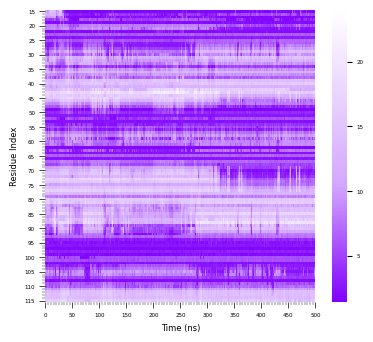

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker

df = heatDat

# 创建自定义颜色映射
# 5以下颜色越小越深，大于等于5的白色
cmap = mcolors.LinearSegmentedColormap.from_list(
    "custom_cmap",
    [(0, "#8000FF"), (0.4, "#D3A7FF"), (1, "#ffffff")],
    N=512
)

# 绘制热图
fig, ax = plt.subplots(figsize=(4, 3.5) )  # 设置图形大小
sns.heatmap(df, annot=False, cmap=cmap)#, norm=norm, fmt=".1f", cbar_kws=cbar_kws)  # 设置颜色条的标签

# major_pos   = range(0, 1001, 50)
# major_label = range(0, 101, 5)
# minor_pos   = range(0, 1001, 10)

major_pos   = range(0, 5001, 500)
major_label = range(0, 501, 50)
minor_pos   = range(0, 5001, 50)

plt.xticks(major_pos, major_label, rotation=0)
ax.xaxis.set_minor_locator(ticker.FixedLocator(minor_pos))
ax.tick_params(axis="x", which="major", direction="out", width=0.5, length=4, right=False,labelsize=4)
ax.tick_params(axis="x", which="minor", direction="out", width=0.3, length=2, right=False)

plt.yticks([x+0.5 for x in range(0, 101, 5)], range(15, 116, 5))
ax.tick_params(axis="y",reset=True, which="both", direction="out", width=0.5, length=4,labelsize=4,right=False)
ax.tick_params(axis="y", which="minor",reset=True, direction="out", width=0.3, length=2,zorder=1,right=False)

ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(5))


cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=4)  # 设置颜色条刻度的字体大小

plt.tight_layout(pad=1.5)

plt.ylabel("Residue Index", fontsize=6)
plt.xlabel("Time (ns)", fontsize=6)

plt.savefig("HeatMap_RNA_3.png", dpi=600)
plt.savefig("HeatMap_RNA_3.svg", dpi=600)
# plt.savefig("HeatMap_test.pdf", dpi=600)
# plt.savefig("HeatMap_test.svg", dpi=600)

plt.show()
